In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 

/opt/anaconda3/lib/python3.13/site-packages/pandas/core/computation/expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [3]:
from sklearn.datasets import make_blobs 

In [27]:
X,y = make_blobs(n_samples = 1000, n_features = 2, centers = 3)

In [28]:
X

array([[ 3.3474397 , -3.43748063],
       [-6.48623225,  0.35188521],
       [ 3.41744095, -3.06441538],
       ...,
       [-5.37833795,  1.76898409],
       [-6.63984823,  0.82708295],
       [ 2.7161855 ,  6.95154178]], shape=(1000, 2))

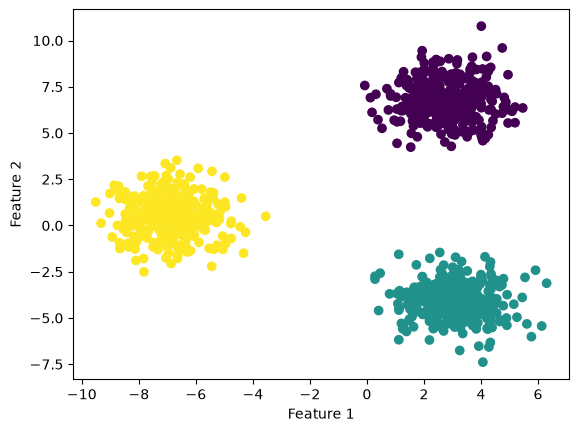

In [29]:
plt.scatter(X[:,0], X[:,1], c=y)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

In [30]:
print(X.shape)
print(y.shape)

(1000, 2)
(1000,)


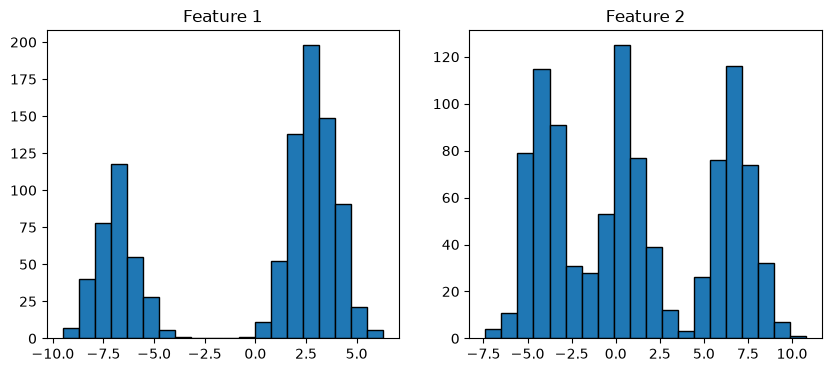

In [31]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.hist(X[:,0], bins = 20, edgecolor='black')
plt.title('Feature 1')
plt.subplot(1,2,2)
plt.hist(X[:,1],bins = 20, edgecolor = 'black')
plt.title('Feature 2')
plt.show()


In [32]:
from sklearn.model_selection import train_test_split 
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.33, random_state = 42)

In [33]:
from sklearn.preprocessing import StandardScaler 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [34]:
#Elbow method to find K values
from sklearn.cluster import KMeans 
wcss = []
for k in range(1,11): 
    kmeans = KMeans(n_clusters=k, init = 'k-means++')
    kmeans.fit(X_train_scaled)
    wcss.append(kmeans.inertia_)

In [35]:
wcss

[1340.0,
 662.9117299980826,
 64.23360873328754,
 56.57317252425581,
 49.41846777001127,
 41.92224690934952,
 38.91874926995934,
 33.951328336459014,
 28.828044943520176,
 26.79113617934346]

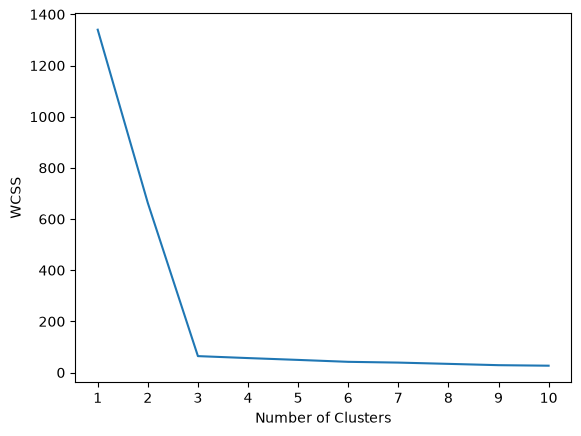

In [36]:
#Plot elbow curves 
plt.plot(range(1,11),wcss)
plt.xticks(range(1,11))
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

In [37]:
kmeans = KMeans(n_clusters = 3, init = 'k-means++')

In [38]:
train_labels = kmeans.fit_predict(X_train_scaled)
y_pred = kmeans.predict(X_test_scaled)

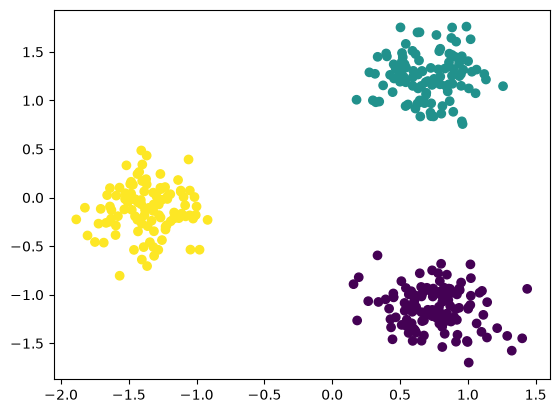

In [39]:
plt.scatter(X_test_scaled[:,0], X_test_scaled[:,1],c = y_pred)

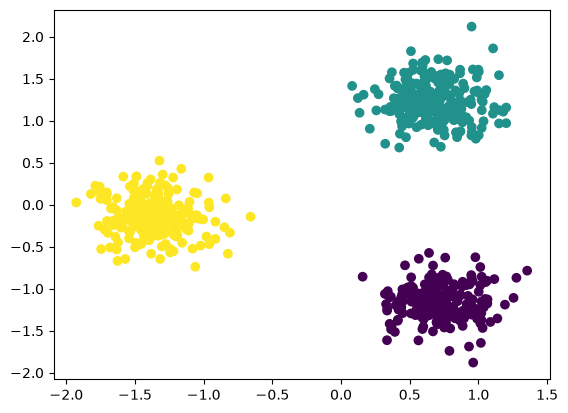

In [40]:
plt.scatter(X_train_scaled[:,0],X_train_scaled[:,1],c=train_labels)

In [41]:
## Validating the k value 
## kneelocator 
## Silhouttee score 

In [19]:
##kneelocator 
!pip install kneed

In [20]:
from kneed import KneeLocator

In [42]:
kl = KneeLocator(range(1,11),wcss,curve = 'convex',direction = 'decreasing')

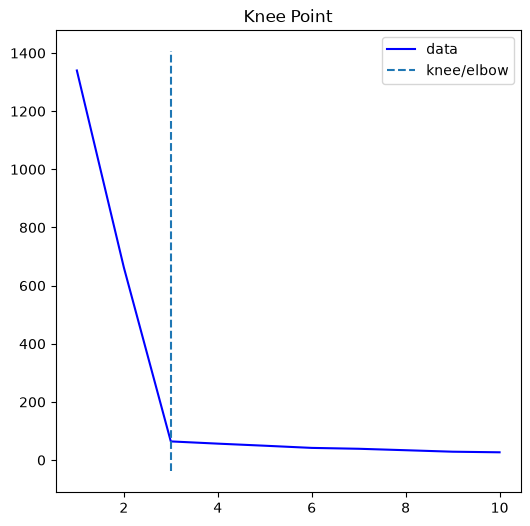

In [43]:
kl.plot_knee() 

In [44]:
from sklearn.metrics import silhouette_score

In [45]:
silhouette_coef = [] 
#for each k, calculate the silhouette_score
for k in range(2,11): 
    kmeans = KMeans(n_clusters = k, init = 'k-means++')
    kmeans.fit(X_train_scaled)
    score = silhouette_score(X_train_scaled, kmeans.labels_)
## X_train_scaled = the point positions 
## kmeans.labels = labels assign for each points 
    silhouette_coef.append(score)


In [46]:
silhouette_coef

[0.5726833213960651,
 0.8305140965186864,
 0.6597497271180365,
 0.48381162949298273,
 0.6432916266062721,
 0.3259600484018663,
 0.3334744464931594,
 0.33608141927101975,
 0.33031612211710953]

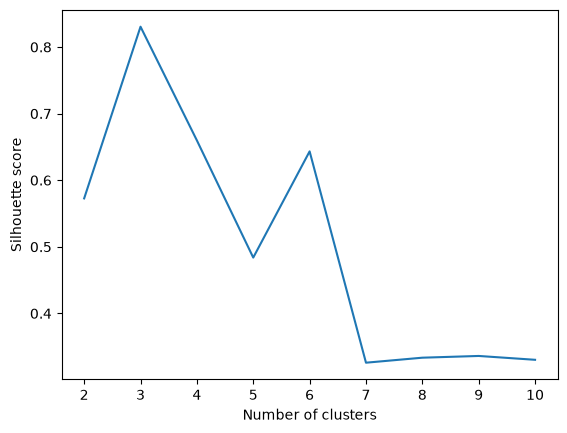

In [47]:
plt.plot(range(2,11), silhouette_coef)
plt.xticks(range(2,11))
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette score')
plt.show()